# EM-DAT Compound Hazard Analysis

This notebook processes EM-DAT disaster records to identify natural disasters with associated natural hazard types, summarize compound-event frequencies, and build hazard co-occurrence networks. It is organized as a reproducible workflow for the open-source repository: configure paths once, run cells from top to bottom, and regenerate the same tables and figures.

**Notes for reuse**

- EM-DAT data are not committed to this repository. Set the input paths in the configuration cell below or provide environment variables.
- The notebook excludes 2025 by default because the source file used in the original analysis was incomplete for that year.
- Optional exports are disabled by default to avoid writing files during exploratory reruns.


## 1. Setup

Import packages, set display options, and define reproducibility constants. The analysis uses deterministic random seeds for network layouts and community detection where the underlying library supports them.


In [188]:
from __future__ import annotations

import os
from collections import Counter
from pathlib import Path

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import networkx as nx
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_SEED = 42
EXCLUDE_START_YEAR = 2025
EXPORT_OUTPUTS = True

plt.rcParams.update({
    "font.family": "Arial",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## 2. Configuration

Update the paths below if your EM-DAT files are stored somewhere else. Environment variables take precedence, which makes the notebook easier to run in different local or CI environments.

- `EMDAT_FILE`: full path to the EM-DAT workbook.
- `EMDAT_TREND_FILE`: full path to the precomputed count/loss trend workbook.
- `EMDAT_OUTPUT_DIR`: output directory for optional generated tables and figures.


In [189]:
PROJECT_ROOT = Path.cwd()

EMDAT_FILE = Path(
    os.getenv("EMDAT_FILE", PROJECT_ROOT / "data" / "raw" / "public_emdat_2025-10-28.xlsx")
).expanduser().resolve()

TREND_WORKBOOK = Path(
    os.getenv("EMDAT_TREND_FILE", PROJECT_ROOT / "data" / "processed" / "natural_assoc_trend.xlsx")
).expanduser().resolve()

OUTPUT_DIR = Path(os.getenv("EMDAT_OUTPUT_DIR", PROJECT_ROOT / "output" / "emdat")).resolve()

# print(f"Project root: {PROJECT_ROOT}")
# print(f"EM-DAT workbook: {EMDAT_FILE}")
# print(f"Trend workbook: {TREND_WORKBOOK}")
# print(f"Output directory: {OUTPUT_DIR}")


## 3. Helper Functions

These functions keep the analysis cells short and reduce hidden state. They also make assumptions explicit: how associated hazards are split, how hazard names are harmonized, and how directed pairs are converted to an undirected co-occurrence network.


In [114]:
from __future__ import annotations


def require_file(path: Path, description: str) -> Path:
    """Return a path if it exists; otherwise raise a clear, actionable error."""
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {description}: {path}\n"
            "Update the configuration cell or set the corresponding environment variable."
        )
    return path


def summarize_categories(df: pd.DataFrame, columns: list[str]) -> None:
    """Print the number and values of unique non-null categories for selected columns."""
    for col in columns:
        values = sorted(df[col].dropna().astype(str).str.strip().unique().tolist())
        print(f"\n--- {col} ---")
        print(f"Unique values: {len(values)}")
        print(values)


def split_associated_types(df: pd.DataFrame, source_col: str = "Associated Types") -> tuple[pd.DataFrame, list[str]]:
    """Split EM-DAT pipe-delimited associated hazard types into separate columns."""
    out = df.copy()
    out["Associated_Type_Count"] = (
        out[source_col]
        .fillna("")
        .astype(str)
        .apply(lambda value: len([item for item in value.split("|") if item.strip()]))
    )

    split_df = out[source_col].str.split("|", expand=True)
    split_df = split_df.apply(lambda col: col.astype("string").str.strip())
    assoc_cols = [f"Associated type{i + 1}" for i in range(split_df.shape[1])]
    split_df.columns = assoc_cols
    return pd.concat([out, split_df], axis=1), assoc_cols


def classify_associated_hazards(
    df: pd.DataFrame,
    assoc_cols: list[str],
    hazard_classification: dict[str, str],
) -> pd.DataFrame:
    """Keep rows with natural associated hazards and blank out non-natural associated labels."""
    out = df.copy()
    natural_set = {hazard for hazard, category in hazard_classification.items() if category == "Natural"}

    for col in assoc_cols:
        out[col] = out[col].apply(lambda value: value.strip() if isinstance(value, str) else value)
        out[f"{col}_Category"] = out[col].map(hazard_classification)
        out[col] = out[col].where(out[col].isin(natural_set), np.nan)

    category_cols = [f"{col}_Category" for col in assoc_cols]
    mask_any_natural = out[assoc_cols].isin(natural_set).any(axis=1)
    out = out.loc[mask_any_natural].copy()
    out["Assoc_Natural_Count"] = out[category_cols].eq("Natural").sum(axis=1)
    return out


def count_directed_hazard_pairs(
    df: pd.DataFrame,
    source_col: str,
    assoc_cols: list[str],
) -> pd.DataFrame:
    """Count directed pairs from a disaster type/subtype to each natural associated hazard."""
    pair_counter = Counter()

    for _, row in df.iterrows():
        source = row[source_col]
        if pd.isna(source):
            continue

        associated = [
            row[col]
            for col in assoc_cols
            if pd.notna(row[col]) and str(row[col]).strip() != ""
        ]
        for target in associated:
            pair_counter[(str(source).strip(), str(target).strip())] += 1

    return (
        pd.DataFrame(
            [(source, target, freq) for (source, target), freq in pair_counter.items()],
            columns=[source_col.replace(" ", "_"), "Associated_Type", "Frequency"],
        )
        .sort_values("Frequency", ascending=False)
        .reset_index(drop=True)
    )


def build_undirected_pairs(
    pair_df: pd.DataFrame,
    source_col: str,
    source_map: dict[str, str] | None = None,
    target_map: dict[str, str] | None = None,
    final_name_map: dict[str, str] | None = None,
) -> pd.DataFrame:
    """Canonicalize directed pairs into weighted undirected hazard co-occurrences."""
    df = pair_df.copy()
    source_map = source_map or {}
    target_map = target_map or {}
    final_name_map = final_name_map or {}

    df[source_col] = df[source_col].astype(str).str.strip().replace(source_map)
    df["Associated_Type"] = df["Associated_Type"].astype(str).str.strip().replace(target_map)

    endpoints = df.apply(
        lambda row: pd.Series(
            sorted([row[source_col], row["Associated_Type"]]),
            index=["Hazard_A", "Hazard_B"],
        ),
        axis=1,
    )

    out = (
        pd.concat([endpoints, df["Frequency"]], axis=1)
        .groupby(["Hazard_A", "Hazard_B"], as_index=False)["Frequency"]
        .sum()
        .rename(columns={"Frequency": "weight"})
    )

    for col in ["Hazard_A", "Hazard_B"]:
        out[col] = out[col].replace(final_name_map)

    return (
        out.loc[out["Hazard_A"] != out["Hazard_B"]]
        .groupby(["Hazard_A", "Hazard_B"], as_index=False)["weight"]
        .sum()
        .sort_values("weight", ascending=False)
        .reset_index(drop=True)
    )


def graph_from_pairs(edge_df: pd.DataFrame) -> nx.Graph:
    """Build a weighted NetworkX graph from canonical hazard pairs."""
    graph = nx.Graph()
    for _, row in edge_df.iterrows():
        graph.add_edge(row["Hazard_A"], row["Hazard_B"], weight=float(row["weight"]))
    return graph


def louvain_cluster_table(graph: nx.Graph, resolution: float = 1.0) -> tuple[dict[str, int], pd.DataFrame]:
    """Run Louvain community detection and return both node mapping and summary table."""
    try:
        communities = nx.algorithms.community.louvain_communities(
            graph,
            weight="weight",
            resolution=resolution,
            seed=RANDOM_SEED,
        )
    except AttributeError as exc:
        raise ImportError(
            "This notebook requires NetworkX 2.6+ for louvain_communities. "
            "Upgrade with `pip install --upgrade networkx`."
        ) from exc

    partition = {
        node: cluster_id
        for cluster_id, community in enumerate(communities)
        for node in community
    }
    table = (
        pd.DataFrame(
            [{"Hazard": node, "Cluster": cluster, "Degree": graph.degree(node)} for node, cluster in partition.items()]
        )
        .sort_values(["Cluster", "Degree", "Hazard"], ascending=[True, False, True])
        .reset_index(drop=True)
    )
    return partition, table


def partition_to_communities(partition: dict[str, int]) -> list[set[str]]:
    """Convert a node-to-cluster mapping into a list of community node sets."""
    communities: dict[int, set[str]] = {}
    for node, cluster_id in partition.items():
        communities.setdefault(cluster_id, set()).add(node)
    return list(communities.values())


def communities_to_partition(communities) -> dict[str, int]:
    """Convert community iterables into stable integer labels."""
    ordered = sorted(
        [set(community) for community in communities],
        key=lambda community: (-len(community), sorted(community)[0] if community else ""),
    )
    return {
        node: cluster_id
        for cluster_id, community in enumerate(ordered)
        for node in community
    }


def coassignment_agreement(reference: dict[str, int], candidate: dict[str, int]) -> float:
    """Measure how often two partitions agree on same-cluster vs. different-cluster node pairs."""
    nodes = sorted(set(reference) & set(candidate))
    if len(nodes) < 2:
        return np.nan

    total_pairs = 0
    agreeing_pairs = 0
    for i, node_a in enumerate(nodes):
        for node_b in nodes[i + 1:]:
            same_reference = reference[node_a] == reference[node_b]
            same_candidate = candidate[node_a] == candidate[node_b]
            agreeing_pairs += same_reference == same_candidate
            total_pairs += 1
    return agreeing_pairs / total_pairs


def partition_modularity(graph: nx.Graph, partition: dict[str, int]) -> float:
    """Calculate weighted modularity for a partition."""
    communities = partition_to_communities(partition)
    return nx.algorithms.community.quality.modularity(graph, communities, weight="weight")


def spectral_partition(graph: nx.Graph, n_clusters: int) -> dict[str, int]:
    """Run weighted spectral clustering if scikit-learn is available."""
    try:
        from sklearn.cluster import SpectralClustering
    except Exception as exc:
        raise ImportError(f"scikit-learn is unavailable: {exc}") from exc

    nodes = list(graph.nodes())
    adjacency = nx.to_numpy_array(graph, nodelist=nodes, weight="weight")
    model = SpectralClustering(
        n_clusters=n_clusters,
        affinity="precomputed",
        assign_labels="kmeans",
        random_state=RANDOM_SEED,
    )
    labels = model.fit_predict(adjacency)
    return dict(zip(nodes, labels))


def _igraph_from_networkx(graph: nx.Graph):
    """Convert a weighted NetworkX graph to igraph while preserving node names."""
    try:
        import igraph as ig
    except Exception as exc:
        raise ImportError(f"python-igraph is unavailable: {exc}") from exc

    nodes = list(graph.nodes())
    node_to_idx = {node: idx for idx, node in enumerate(nodes)}
    edges = [(node_to_idx[u], node_to_idx[v]) for u, v in graph.edges()]
    weights = [graph[u][v].get("weight", 1.0) for u, v in graph.edges()]

    igraph_graph = ig.Graph(n=len(nodes), edges=edges, directed=False)
    igraph_graph.vs["name"] = nodes
    igraph_graph.es["weight"] = weights
    return igraph_graph


def walktrap_partition(graph: nx.Graph) -> dict[str, int]:
    """Run Walktrap community detection through python-igraph."""
    igraph_graph = _igraph_from_networkx(graph)
    clustering = igraph_graph.community_walktrap(weights="weight").as_clustering()
    communities = [
        {igraph_graph.vs[node_idx]["name"] for node_idx in community}
        for community in clustering
    ]
    return communities_to_partition(communities)


def infomap_partition(graph: nx.Graph) -> dict[str, int]:
    """Run Infomap community detection if the infomap package is available."""
    try:
        from infomap import Infomap
    except Exception as exc:
        raise ImportError(f"infomap is unavailable: {exc}") from exc

    nodes = list(graph.nodes())
    node_to_idx = {node: idx for idx, node in enumerate(nodes)}
    idx_to_node = {idx: node for node, idx in node_to_idx.items()}

    # two_level gives a compact partition comparable to the other methods.
    im = Infomap("--two-level --silent")
    for u, v, data in graph.edges(data=True):
        im.add_link(node_to_idx[u], node_to_idx[v], float(data.get("weight", 1.0)))
    im.run()

    return {
        idx_to_node[node.node_id]: node.module_id
        for node in im.tree
        if node.is_leaf and node.node_id in idx_to_node
    }


def run_community_robustness(graph: nx.Graph, reference_partition: dict[str, int]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Compare Louvain with alternative community detection algorithms."""
    reference_clusters = len(set(reference_partition.values()))
    results: list[dict[str, object]] = []
    partitions: dict[str, dict[str, int]] = {"Louvain (main)": reference_partition}

    candidates = [
        (
            "Greedy modularity",
            lambda: communities_to_partition(
                nx.algorithms.community.greedy_modularity_communities(graph, weight="weight")
            ),
            "Weighted modularity optimization; deterministic in NetworkX.",
        ),
        (
            "Label propagation",
            lambda: communities_to_partition(nx.algorithms.community.label_propagation_communities(graph)),
            "Unweighted semi-synchronous label propagation.",
        ),
        (
            "Async label propagation",
            lambda: communities_to_partition(
                nx.algorithms.community.asyn_lpa_communities(graph, weight="weight", seed=RANDOM_SEED)
            ),
            "Weighted asynchronous label propagation with fixed seed.",
        ),
        (
            "Girvan-Newman",
            lambda: communities_to_partition(_girvan_newman_to_k(graph, reference_clusters)),
            "Edge-betweenness hierarchy cut to the Louvain cluster count.",
        ),
        (
            "Infomap",
            lambda: infomap_partition(graph),
            "Flow-based information-theoretic community detection; optional infomap dependency.",
        ),
        (
            "Walktrap",
            lambda: walktrap_partition(graph),
            "Random-walk community detection; optional python-igraph dependency.",
        ),
        (
            "Spectral clustering",
            lambda: spectral_partition(graph, reference_clusters),
            "Weighted adjacency spectral clustering with the Louvain cluster count.",
        ),
    ]

    for algorithm, candidate_func, notes in candidates:
        try:
            partitions[algorithm] = candidate_func()
        except Exception as exc:
            results.append({
                "Algorithm": algorithm,
                "Status": "Skipped",
                "Clusters": np.nan,
                "Modularity": np.nan,
                "Agreement_with_Louvain": np.nan,
                "Notes": f"{notes} Skipped because: {exc}",
            })

    for algorithm, candidate_partition in partitions.items():
        results.append({
            "Algorithm": algorithm,
            "Status": "OK",
            "Clusters": len(set(candidate_partition.values())),
            "Modularity": partition_modularity(graph, candidate_partition),
            "Agreement_with_Louvain": (
                1.0
                if algorithm == "Louvain (main)"
                else coassignment_agreement(reference_partition, candidate_partition)
            ),
            "Notes": "Reference partition." if algorithm == "Louvain (main)" else "Robustness comparison.",
        })

    summary = (
        pd.DataFrame(results)
        .sort_values(["Status", "Agreement_with_Louvain", "Modularity"], ascending=[True, False, False])
        .reset_index(drop=True)
    )

    assignment_table = pd.DataFrame({"Hazard": sorted(graph.nodes())})
    for algorithm, candidate_partition in partitions.items():
        assignment_table[algorithm] = assignment_table["Hazard"].map(candidate_partition)

    return summary, assignment_table


def _girvan_newman_to_k(graph: nx.Graph, n_clusters: int) -> tuple[set[str], ...]:
    """Return the first Girvan-Newman partition with at least n_clusters communities."""
    if n_clusters <= 1:
        return (set(graph.nodes()),)

    generator = nx.algorithms.community.girvan_newman(graph)
    communities = (set(graph.nodes()),)
    for communities in generator:
        if len(communities) >= n_clusters:
            return tuple(set(community) for community in communities)
    return tuple(set(community) for community in communities)


def show_latex_table(df: pd.DataFrame, caption: str, label: str) -> None:
    """Print a LaTeX table block without writing to disk."""
    latex_table = df.to_latex(index=False, caption=caption, label=label)
    print(latex_table)


## 4. Load and Validate EM-DAT Data

Load the `EM-DAT Data` worksheet, remove the incomplete year, and inspect the main hazard classification fields.


In [115]:
emdat_df = pd.read_excel(require_file(EMDAT_FILE, "EM-DAT workbook"), sheet_name="EM-DAT Data")
emdat_df = emdat_df.loc[emdat_df["Start Year"] != EXCLUDE_START_YEAR].copy()

print(f"Rows after excluding {EXCLUDE_START_YEAR}: {emdat_df.shape[0]:,}")
print(f"Columns: {emdat_df.shape[1]:,}")
emdat_df.head()


Rows after excluding 2025: 16,147
Columns: 46


,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,Country,Subregion,Region,Location,Origin,Associated Types,OFDA/BHA Response,Appeal,Declaration,AID Contribution ('000 US$),Magnitude,Magnitude Scale,Latitude,Longitude,River Basin,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,Entry Date,Last Update
0,1999-9388-DJI,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,DJI,Djibouti,Sub-Saharan Africa,Africa,"Ali Sabieh, Dikhil, Djibouti, Obock, Tadjourah...",NaN,NaN,Yes,No,No,1556.0,NaN,Km2,NaN,NaN,NaN,2001,6.0,NaN,2001,NaN,NaN,NaN,NaN,100000.0,NaN,100000.0,NaN,NaN,NaN,NaN,NaN,NaN,56.446576,"[{""adm1_code"":1093,""adm1_name"":""Ali Sabieh""},{...",2006-03-01,2023-09-25
1,1999-9388-SDN,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,SDN,Sudan,Northern Africa,Africa,"Northern Darfur, Northern Kordofan, Red Sea pr...",NaN,Food shortage|Water shortage,No,No,No,NaN,NaN,Km2,NaN,NaN,NaN,2000,1.0,NaN,2001,NaN,NaN,NaN,NaN,2000000.0,NaN,2000000.0,NaN,NaN,NaN,NaN,NaN,NaN,54.895152,"[{""adm1_code"":2757,""adm1_name"":""Northern Darfu...",2006-03-08,2023-09-25
2,1999-9388-SOM,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,SOM,Somalia,Sub-Saharan Africa,Africa,"Ceel Barde, Rab Dhuure, Tayeeglow, Xudur distr...",NaN,Food shortage,No,No,No,NaN,NaN,Km2,NaN,NaN,NaN,2000,1.0,NaN,2001,NaN,NaN,21.0,NaN,1200000.0,NaN,1200000.0,NaN,NaN,NaN,NaN,NaN,NaN,54.895152,"[{""adm1_code"":2691,""adm1_name"":""Bay""},{""adm1_c...",2006-03-08,2023-09-25
3,2000-0001-AGO,No,tec-tra-roa-roa,Technological,Transport,Road,Road,NaN,NaN,AGO,Angola,Sub-Saharan Africa,Africa,Calulo,NaN,NaN,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,2000,1.0,26.0,2000,1.0,26.0,14.0,11.0,NaN,NaN,11.0,NaN,NaN,NaN,NaN,NaN,NaN,54.895152,NaN,2004-10-27,2023-09-25
4,2000-0002-AGO,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,AGO,Angola,Sub-Saharan Africa,Africa,"Dombre Grande village (Baia Farta district, Be...",Heavy rain,NaN,No,No,Yes,NaN,47000.0,Km2,NaN,NaN,"Coporolo, Kwanza, Lucala",2000,1.0,8.0,2000,1.0,15.0,31.0,NaN,70000.0,NaN,70000.0,NaN,NaN,NaN,NaN,10000.0,18217.0,54.895152,"[{""adm2_code"":4214,""adm2_name"":""Baia Farta""},{...",2005-02-03,2023-09-25


In [116]:
HAZARD_COLUMNS = [
    "Disaster Group",
    "Disaster Subgroup",
    "Disaster Type",
    "Disaster Subtype",
    "Associated Types",
]

summarize_categories(emdat_df, HAZARD_COLUMNS)



--- Disaster Group ---
Unique values: 2
['Natural', 'Technological']

--- Disaster Subgroup ---
Unique values: 9
['Biological', 'Climatological', 'Extra-terrestrial', 'Geophysical', 'Hydrological', 'Industrial accident', 'Meteorological', 'Miscellaneous accident', 'Transport']

--- Disaster Type ---
Unique values: 31
['Air', 'Animal incident', 'Chemical spill', 'Collapse (Industrial)', 'Collapse (Miscellaneous)', 'Drought', 'Earthquake', 'Epidemic', 'Explosion (Industrial)', 'Explosion (Miscellaneous)', 'Extreme temperature', 'Fire (Industrial)', 'Fire (Miscellaneous)', 'Flood', 'Gas leak', 'Glacial lake outburst flood', 'Impact', 'Industrial accident (General)', 'Infestation', 'Mass movement (dry)', 'Mass movement (wet)', 'Miscellaneous accident (General)', 'Oil spill', 'Poisoning', 'Radiation', 'Rail', 'Road', 'Storm', 'Volcanic activity', 'Water', 'Wildfire']

--- Disaster Subtype ---
Unique values: 63
['Air', 'Animal incident', 'Ash fall', 'Avalanche (dry)', 'Avalanche (wet)', 'Ba

## 5. Natural Disasters with Associated Natural Hazards

The analysis focuses on natural disaster records and treats non-empty `Associated Types` values as potential compound or cascading hazards. Associated hazard labels are split, classified, and filtered so downstream pair counts use natural associated hazards only.


In [117]:
natural_df = emdat_df.loc[emdat_df["Disaster Group"] == "Natural"].copy()
print(f"Natural disaster records: {natural_df.shape[0]:,}")
natural_df.head()


Natural disaster records: 10,289


,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,Country,Subregion,Region,Location,Origin,Associated Types,OFDA/BHA Response,Appeal,Declaration,AID Contribution ('000 US$),Magnitude,Magnitude Scale,Latitude,Longitude,River Basin,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,Entry Date,Last Update
0,1999-9388-DJI,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,DJI,Djibouti,Sub-Saharan Africa,Africa,"Ali Sabieh, Dikhil, Djibouti, Obock, Tadjourah...",NaN,NaN,Yes,No,No,1556.0,NaN,Km2,NaN,NaN,NaN,2001,6.0,NaN,2001,NaN,NaN,NaN,NaN,100000.0,NaN,100000.0,NaN,NaN,NaN,NaN,NaN,NaN,56.446576,"[{""adm1_code"":1093,""adm1_name"":""Ali Sabieh""},{...",2006-03-01,2023-09-25
1,1999-9388-SDN,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,SDN,Sudan,Northern Africa,Africa,"Northern Darfur, Northern Kordofan, Red Sea pr...",NaN,Food shortage|Water shortage,No,No,No,NaN,NaN,Km2,NaN,NaN,NaN,2000,1.0,NaN,2001,NaN,NaN,NaN,NaN,2000000.0,NaN,2000000.0,NaN,NaN,NaN,NaN,NaN,NaN,54.895152,"[{""adm1_code"":2757,""adm1_name"":""Northern Darfu...",2006-03-08,2023-09-25
2,1999-9388-SOM,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,SOM,Somalia,Sub-Saharan Africa,Africa,"Ceel Barde, Rab Dhuure, Tayeeglow, Xudur distr...",NaN,Food shortage,No,No,No,NaN,NaN,Km2,NaN,NaN,NaN,2000,1.0,NaN,2001,NaN,NaN,21.0,NaN,1200000.0,NaN,1200000.0,NaN,NaN,NaN,NaN,NaN,NaN,54.895152,"[{""adm1_code"":2691,""adm1_name"":""Bay""},{""adm1_c...",2006-03-08,2023-09-25
4,2000-0002-AGO,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,AGO,Angola,Sub-Saharan Africa,Africa,"Dombre Grande village (Baia Farta district, Be...",Heavy rain,NaN,No,No,Yes,NaN,47000.0,Km2,NaN,NaN,"Coporolo, Kwanza, Lucala",2000,1.0,8.0,2000,1.0,15.0,31.0,NaN,70000.0,NaN,70000.0,NaN,NaN,NaN,NaN,10000.0,18217.0,54.895152,"[{""adm2_code"":4214,""adm2_name"":""Baia Farta""},{...",2005-02-03,2023-09-25
5,2000-0003-BGD,No,nat-met-ext-col,Natural,Meteorological,Extreme temperature,Cold wave,NaN,NaN,BGD,Bangladesh,Southern Asia,Asia,"Barisal, Chittagong, Dhaka, Khulna, Rajshahi, ...",NaN,NaN,No,No,No,NaN,6.4,°C,NaN,NaN,NaN,2000,1.0,NaN,2000,1.0,NaN,49.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.895152,"[{""adm1_code"":575,""adm1_name"":""Barisal""},{""adm...",2003-07-01,2023-09-25


In [118]:
emdat_expanded, assoc_cols = split_associated_types(natural_df)
print(f"Associated hazard columns: {assoc_cols}")
emdat_expanded[["Disaster Type", "Disaster Subtype", "Associated Types", *assoc_cols]].head()


Associated hazard columns: ['Associated type1', 'Associated type2', 'Associated type3', 'Associated type4']


,Disaster Type,Disaster Subtype,Associated Types,Associated type1,Associated type2,Associated type3,Associated type4
0,Drought,Drought,NaN,<NA>,<NA>,<NA>,<NA>
1,Drought,Drought,Food shortage|Water shortage,Food shortage,Water shortage,<NA>,<NA>
2,Drought,Drought,Food shortage,Food shortage,<NA>,<NA>,<NA>
4,Flood,Riverine flood,NaN,<NA>,<NA>,<NA>,<NA>
5,Extreme temperature,Cold wave,NaN,<NA>,<NA>,<NA>,<NA>


In [119]:
unique_associated = sorted(
    {
        str(value).strip()
        for value in emdat_expanded[assoc_cols].to_numpy().ravel()
        if pd.notna(value) and str(value).strip()
    }
)

print(f"Unique associated hazard labels: {len(unique_associated)}")
unique_associated


Unique associated hazard labels: 34


['Avalanche (Snow, Debris)',
 'Broken Dam/Burst bank',
 'Cold wave',
 'Collapse',
 'Crop failure',
 'Drought',
 'Earthquake',
 'Epidemic',
 'Explosion',
 'Famine',
 'Fire',
 'Flood',
 'Fog',
 'Food shortage',
 'Hail',
 'Heat wave',
 'Industrial accidents',
 'Insect infestation',
 'Intoxication',
 'Lightening',
 'Liquefaction',
 'Oil spill',
 'Pollution',
 'Rain',
 'Severe winter conditions',
 'Slide (land, mud, snow, rock)',
 'Snow/ice',
 'Storm',
 'Surge',
 'Transport accident',
 'Tsunami/Tidal wave',
 'Volcanic activity',
 'Water shortage',
 'Wildfire']

In [160]:
HAZARD_CLASSIFICATION = {
    # Natural
    "Earthquake": "Natural",
    "Volcanic activity": "Natural",
    "Flood": "Natural",
    "Cold wave": "Natural",
    "Heat wave": "Natural",
    "Drought": "Natural",
    "Storm": "Natural",
    "Rain": "Natural",
    "Hail": "Natural",
    "Surge": "Natural",
    "Snow/ice": "Natural",
    "Severe winter conditions": "Natural",
    "Fog": "Natural",
    "Lightning": "Natural",
    "Slide (land, mud, snow, rock)": "Natural",
    "Avalanche (Snow, Debris)": "Natural",
    "Insect infestation": "Natural",
    "Wildfire": "Natural",

    # Technological
    "Fire": "Technological",
    "Collapse": "Technological",
    "Explosion": "Technological",
    "Pollution": "Technological",
    "Industrial accidents": "Technological",
    "Transport accident": "Technological",
    "Oil spill": "Technological",
    "Liquefaction": "Technological",
    "Intoxication": "Technological",
    "Broken Dam/Burst bank": "Technological",

    # Socio-environmental
    "Food shortage": "Socio-environmental",
    "Water shortage": "Socio-environmental",
    "Famine": "Socio-environmental",
    "Crop failure": "Socio-environmental",
    "Epidemic": "Socio-environmental"
}


In [161]:
emdat_natural_assoc = classify_associated_hazards(
    emdat_expanded,
    assoc_cols=assoc_cols,
    hazard_classification=HAZARD_CLASSIFICATION,
)

print(f"Natural disaster records with at least one natural associated hazard: {emdat_natural_assoc.shape[0]:,}")
emdat_natural_assoc[["Disaster Type", "Disaster Subtype", "Associated Types", "Assoc_Natural_Count", *assoc_cols]].head()


Natural disaster records with at least one natural associated hazard: 2,922


,Disaster Type,Disaster Subtype,Associated Types,Assoc_Natural_Count,Associated type1,Associated type2,Associated type3,Associated type4
20,Flood,Riverine flood,"Slide (land, mud, snow, rock)",1,"Slide (land, mud, snow, rock)",NaN,NaN,NaN
38,Flood,Flash flood,"Slide (land, mud, snow, rock)",1,"Slide (land, mud, snow, rock)",NaN,NaN,NaN
49,Storm,Storm (General),Cold wave,1,Cold wave,NaN,NaN,NaN
74,Flood,Riverine flood,"Slide (land, mud, snow, rock)",1,"Slide (land, mud, snow, rock)",NaN,NaN,NaN
88,Storm,Tropical cyclone,Flood,1,Flood,NaN,NaN,NaN


## 6. Frequency Tables

Summarize how many natural associated hazards appear per event and identify the primary disaster types and subtypes most often linked to associated natural hazards.


In [162]:
natural_count = (
    emdat_natural_assoc.groupby("Assoc_Natural_Count")
    .size()
    .reset_index(name="Frequency")
    .sort_values("Assoc_Natural_Count")
)

natural_count


,Assoc_Natural_Count,Frequency
0,1,2329
1,2,583
2,3,9
3,4,1


In [163]:
TYPE_MERGE_MAP = {
    "Severe winter conditions": "Cold wave",
    "Glacial lake outburst flood": "Flood",
}

SUBTYPE_MERGE_MAP = {
    "Severe winter conditions": "Cold wave",
    "Glacial lake outburst flood": "Flood (General)",
}

emdat_natural_assoc = emdat_natural_assoc.copy()
emdat_natural_assoc["Disaster Type"] = emdat_natural_assoc["Disaster Type"].replace(TYPE_MERGE_MAP)
emdat_natural_assoc["Disaster Subtype"] = emdat_natural_assoc["Disaster Subtype"].replace(SUBTYPE_MERGE_MAP)

frequent_subtype = (
    emdat_natural_assoc.groupby(["Disaster Type", "Disaster Subtype"])
    .size()
    .reset_index(name="Frequency")
    .sort_values("Frequency", ascending=False)
    .reset_index(drop=True)
)

frequent_subtype.head(20)


,Disaster Type,Disaster Subtype,Frequency
0,Storm,Tropical cyclone,737
1,Flood,Riverine flood,570
2,Flood,Flood (General),436
3,Flood,Flash flood,239
4,Storm,Severe weather,154
5,Storm,Storm (General),135
6,Earthquake,Ground movement,103
7,Storm,Lightning/Thunderstorms,86
8,Storm,Blizzard/Winter storm,82
9,Storm,Tornado,57


In [164]:
frequent_type = (
    frequent_subtype.groupby("Disaster Type", as_index=False)["Frequency"]
    .sum()
    .sort_values("Frequency", ascending=False)
    .reset_index(drop=True)
)

frequent_type


,Disaster Type,Frequency
0,Storm,1329
1,Flood,1252
2,Earthquake,106
3,Extreme temperature,80
4,Mass movement (wet),71
5,Wildfire,37
6,Drought,34
7,Volcanic activity,13


In [165]:
show_latex_table(
    frequent_subtype,
    caption="Frequency of disaster subtypes associated with other natural hazard types in EM-DAT.",
    label="tab:frequent_subtypes",
)


\begin{table}
\caption{Frequency of disaster subtypes associated with other natural hazard types in EM-DAT.}
\label{tab:frequent_subtypes}
\begin{tabular}{llr}
\toprule
Disaster Type & Disaster Subtype & Frequency \\
\midrule
Storm & Tropical cyclone & 737 \\
Flood & Riverine flood & 570 \\
Flood & Flood (General) & 436 \\
Flood & Flash flood & 239 \\
Storm & Severe weather & 154 \\
Storm & Storm (General) & 135 \\
Earthquake & Ground movement & 103 \\
Storm & Lightning/Thunderstorms & 86 \\
Storm & Blizzard/Winter storm & 82 \\
Storm & Tornado & 57 \\
Extreme temperature & Cold wave & 56 \\
Mass movement (wet) & Landslide (wet) & 52 \\
Storm & Extra-tropical storm & 36 \\
Drought & Drought & 34 \\
Storm & Hail & 30 \\
Extreme temperature & Heat wave & 24 \\
Wildfire & Forest fire & 20 \\
Mass movement (wet) & Mudslide & 13 \\
Wildfire & Wildfire (General) & 11 \\
Volcanic activity & Ash fall & 8 \\
Storm & Sand/Dust storm & 7 \\
Flood & Coastal flood & 7 \\
Mass movement (wet) & Avala

## 7. Hazard Co-Occurrence Network

Each record contributes a directed pair from the recorded disaster type to each natural associated hazard. For the network, pairs are canonicalized into undirected weighted edges so `Flood-Storm` and `Storm-Flood` are counted together.


In [166]:
pair_df = count_directed_hazard_pairs(
    emdat_natural_assoc,
    source_col="Disaster Type",
    assoc_cols=assoc_cols,
)

print(f"Directed disaster-type to associated-hazard pairs: {pair_df.shape[0]:,}")
pair_df.head(20)


Directed disaster-type to associated-hazard pairs: 51


,Disaster_Type,Associated_Type,Frequency
0,Flood,"Slide (land, mud, snow, rock)",1074
1,Storm,Flood,968
2,Storm,"Slide (land, mud, snow, rock)",382
3,Storm,Hail,191
4,Flood,Storm,117
5,Earthquake,"Slide (land, mud, snow, rock)",104
6,Storm,Rain,90
7,Flood,Rain,87
8,Storm,Surge,75
9,Storm,Cold wave,65


In [ ]:
# Reclassify
SOURCE_NAME_MAP = {"Mass movement (wet)": "Mass movement"}

TARGET_NAME_MAP = {
    "Glacial lake outburst flood": "Flood",
    "Hail": "Storm",
    "Surge": "Storm",
    "Cold wave": "Extreme temperature",
    "Heat wave": "Extreme temperature",
    "Avalanche (Snow, Debris)": "Mass movement",
    "Severe winter conditions": "Extreme temperature",
}

FINAL_HAZARD_NAME_MAP = {
    "Rain": "Extreme rainfall",
    "Snow/ice": "Snow/ice extremes",
    "Slide (land, mud, snow, rock)": "Mass movement",
    "Insect infestation": "Infestation",
    "Lightening": "Lightning",
    "Tsunami/Tidal wave": "Tsunami/tidal wave",
}

undirected_df = build_undirected_pairs(
    pair_df,
    source_col="Disaster_Type",
    source_map=SOURCE_NAME_MAP,
    target_map=TARGET_NAME_MAP,
    final_name_map=FINAL_HAZARD_NAME_MAP,
)

undirected_df.head(20)


,Hazard_A,Hazard_B,weight
0,Flood,Mass movement,1129
1,Flood,Storm,1113
2,Mass movement,Storm,397
3,Earthquake,Mass movement,105
4,Extreme rainfall,Storm,90
5,Flood,Extreme rainfall,87
6,Extreme temperature,Storm,68
7,Extreme temperature,Snow/ice extremes,48
8,Drought,Extreme temperature,46
9,Extreme temperature,Wildfire,43


In [168]:
top10_pairs = undirected_df.head(10)
show_latex_table(
    top10_pairs,
    caption="Top 10 most frequently co-occurring natural hazard pairs in EM-DAT.",
    label="tab:frequent_pairs",
)

top10_pairs


\begin{table}
\caption{Top 10 most frequently co-occurring natural hazard pairs in EM-DAT.}
\label{tab:frequent_pairs}
\begin{tabular}{llr}
\toprule
Hazard_A & Hazard_B & weight \\
\midrule
Flood & Mass movement & 1129 \\
Flood & Storm & 1113 \\
Mass movement & Storm & 397 \\
Earthquake & Mass movement & 105 \\
Extreme rainfall & Storm & 90 \\
Flood & Extreme rainfall & 87 \\
Extreme temperature & Storm & 68 \\
Extreme temperature & Snow/ice extremes & 48 \\
Drought & Extreme temperature & 46 \\
Extreme temperature & Wildfire & 43 \\
\bottomrule
\end{tabular}
\end{table}



,Hazard_A,Hazard_B,weight
0,Flood,Mass movement,1129
1,Flood,Storm,1113
2,Mass movement,Storm,397
3,Earthquake,Mass movement,105
4,Extreme rainfall,Storm,90
5,Flood,Extreme rainfall,87
6,Extreme temperature,Storm,68
7,Extreme temperature,Snow/ice extremes,48
8,Drought,Extreme temperature,46
9,Extreme temperature,Wildfire,43


In [169]:
hazard_graph = graph_from_pairs(undirected_df)
partition, cluster_df = louvain_cluster_table(hazard_graph, resolution=1.0)

print(f"Network nodes: {hazard_graph.number_of_nodes():,}")
print(f"Network edges: {hazard_graph.number_of_edges():,}")
print(f"Detected clusters: {cluster_df['Cluster'].nunique():,}")
cluster_df


Network nodes: 12
Network edges: 28
Detected clusters: 3


,Hazard,Cluster,Degree
0,Flood,0,9
1,Mass movement,0,7
2,Storm,0,7
3,Extreme rainfall,0,5
4,Infestation,0,1
5,Earthquake,1,4
6,Volcanic activity,1,4
7,Extreme temperature,2,8
8,Snow/ice extremes,2,4
9,Wildfire,2,4


### Community Detection Robustness Check

Louvain is the main community detection method for the hazard network. As a robustness check, the next cells compare its partition against several alternative algorithms: greedy modularity, label propagation, asynchronous label propagation, Girvan-Newman, Infomap, Walktrap, and spectral clustering. Agreement is calculated as the share of node pairs for which an alternative method matches Louvain on whether the two hazards belong to the same community.


In [170]:
robustness_summary, robustness_assignments = run_community_robustness(hazard_graph, partition)

robustness_summary


,Algorithm,Status,Clusters,Modularity,Agreement_with_Louvain,Notes
0,Louvain (main),OK,3,8.714984e-02,1.000000,Reference partition.
1,Greedy modularity,OK,3,8.714984e-02,1.000000,Robustness comparison.
2,Spectral clustering,OK,3,8.534877e-02,0.909091,Robustness comparison.
3,Async label propagation,OK,2,8.564773e-02,0.848485,Robustness comparison.
4,Infomap,OK,2,8.564773e-02,0.848485,Robustness comparison.
5,Walktrap,OK,3,8.562701e-02,0.818182,Robustness comparison.
6,Girvan-Newman,OK,3,-6.280746e-07,0.393939,Robustness comparison.
7,Label propagation,OK,1,0.000000e+00,0.318182,Robustness comparison.


In [ ]:
robustness_assignments

,Hazard,Louvain (main),Greedy modularity,Label propagation,Async label propagation,Girvan-Newman,Infomap,Walktrap,Spectral clustering
0,Drought,2,0,0,1,0,2,1,2
1,Earthquake,1,2,0,0,0,1,0,1
2,Extreme rainfall,0,1,0,0,0,1,0,1
3,Extreme temperature,2,0,0,1,0,2,1,2
4,Flood,0,1,0,0,0,1,0,1
5,Fog,2,0,0,1,1,2,1,2
6,Infestation,0,1,0,0,2,1,2,1
7,Mass movement,0,1,0,0,0,1,0,1
8,Snow/ice extremes,2,0,0,1,0,2,1,2
9,Storm,0,1,0,0,0,1,0,1


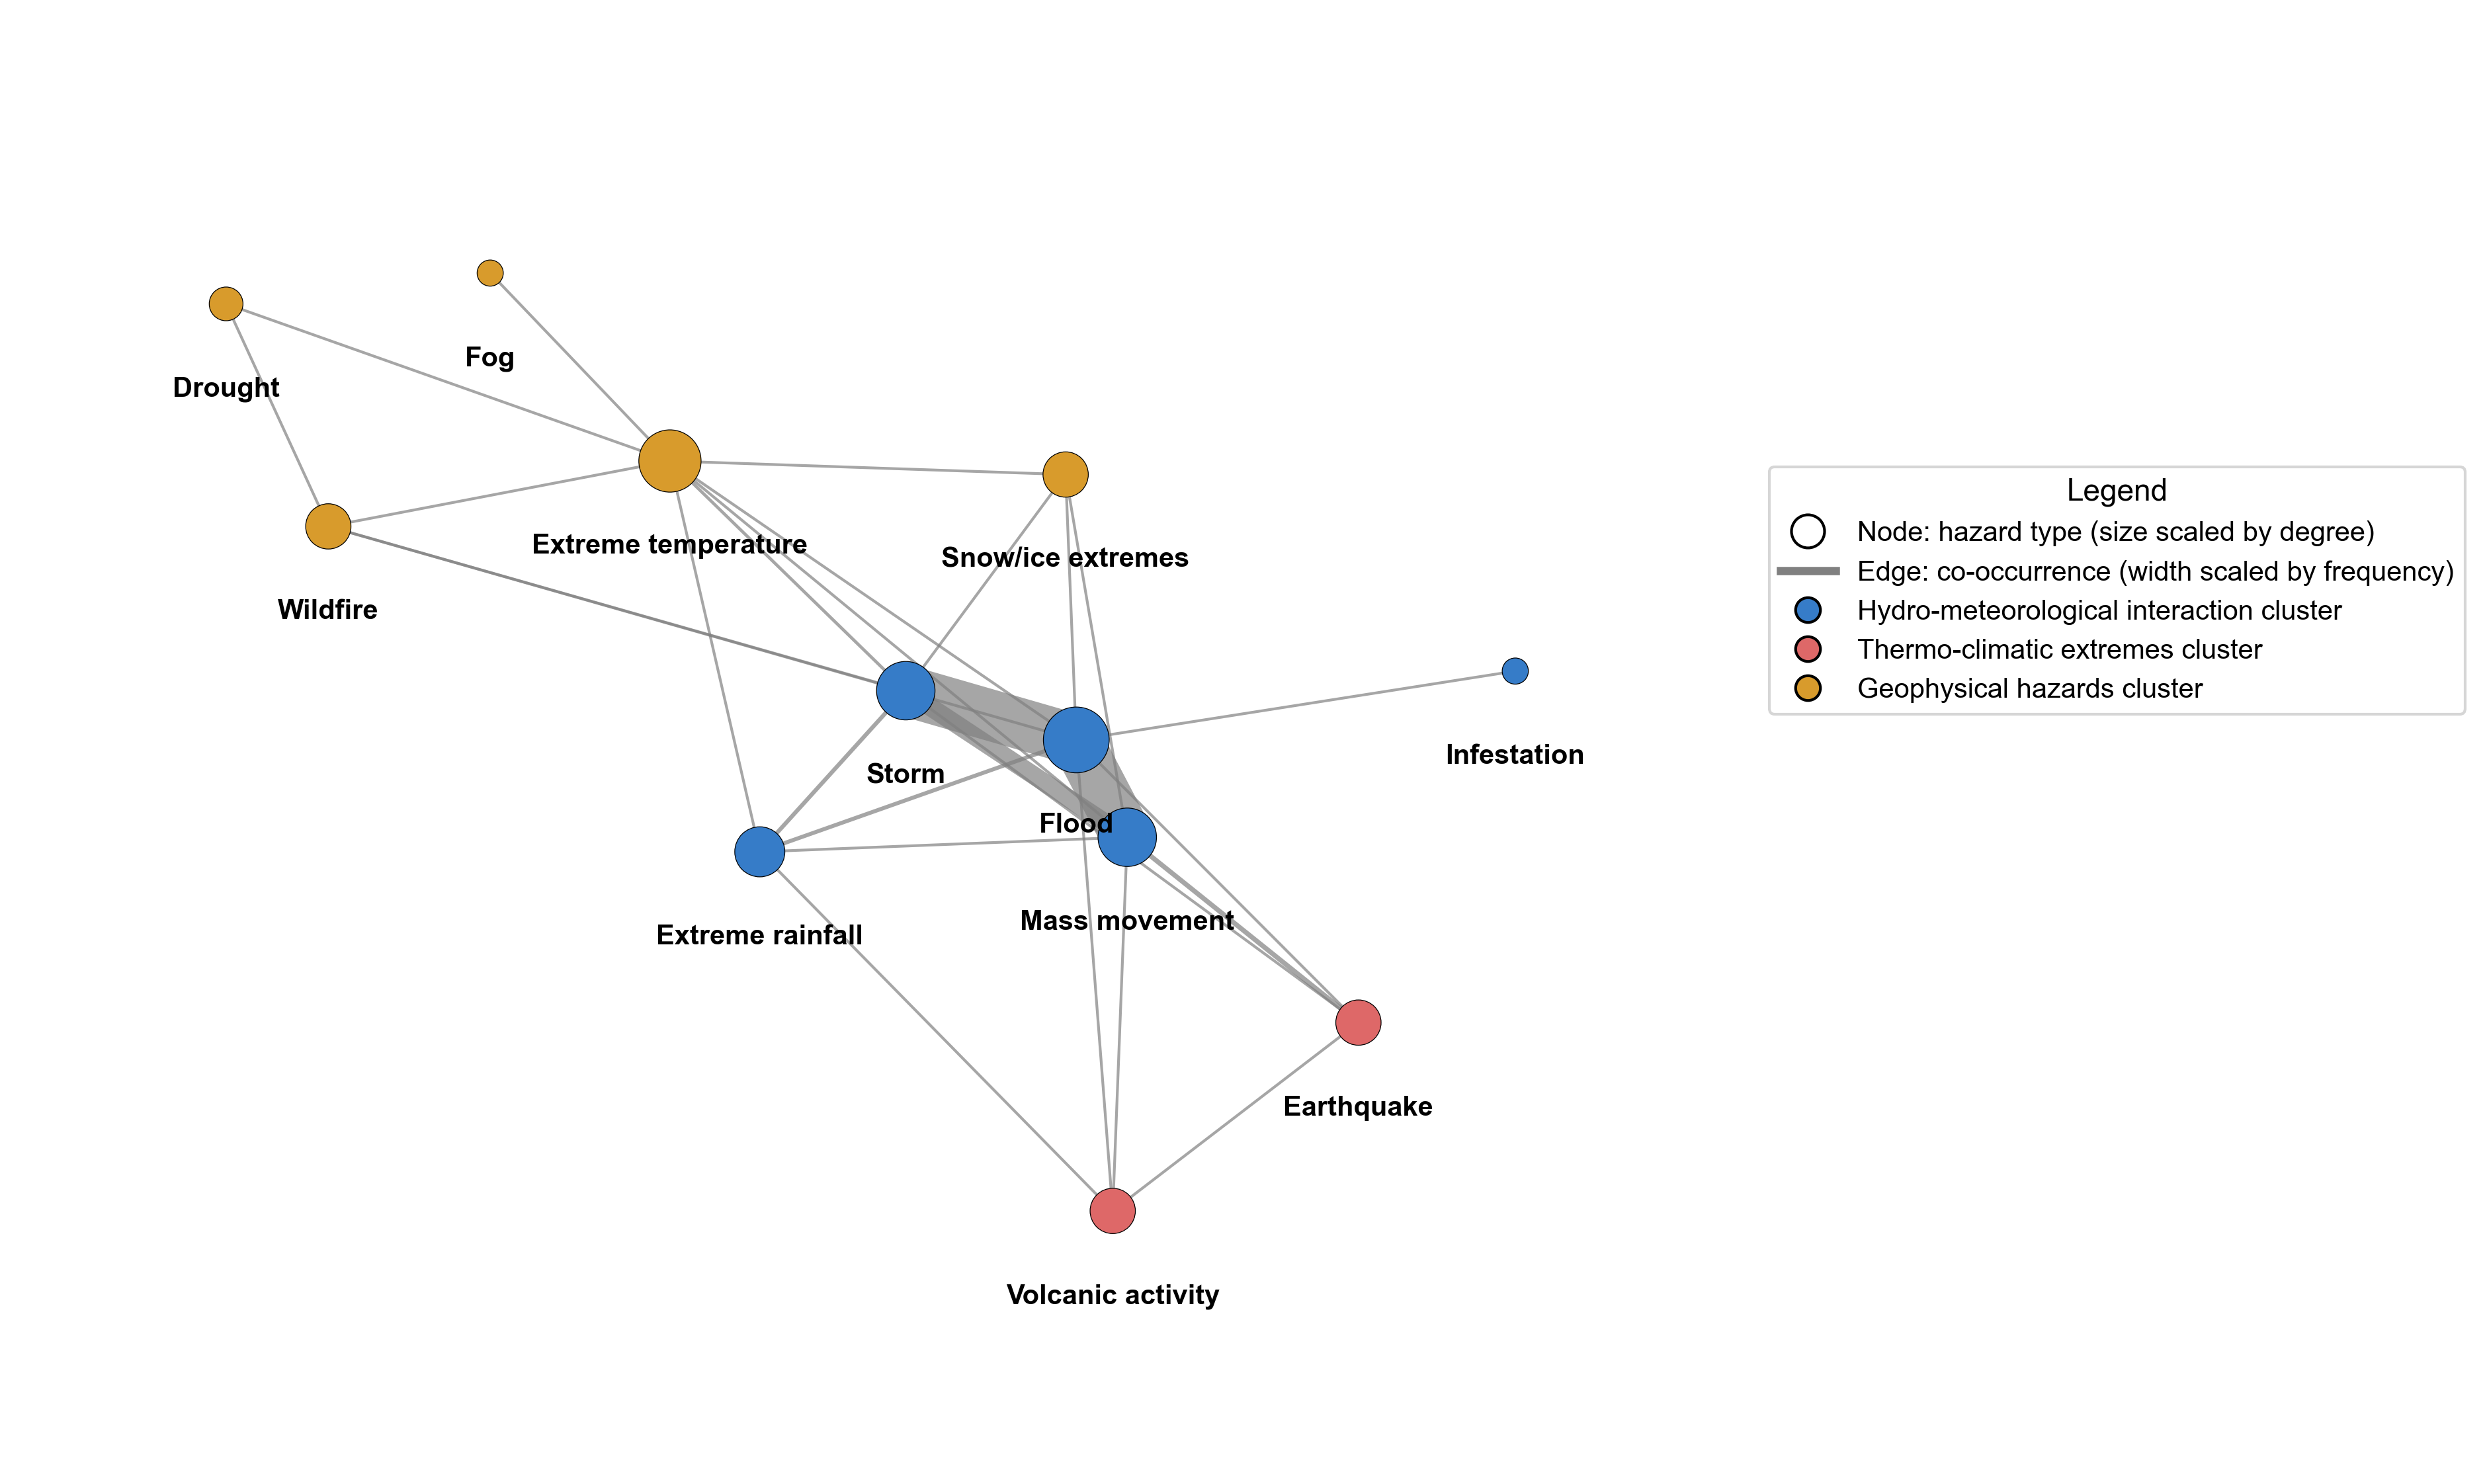

In [ ]:
PALETTE = [
    "#367CC8", "#DE6868", "#D89B2C", "#5E8C61", "#9467BD",
    "#8C564B", "#E377C2", "#7F7F7F", "#BCBD22", "#17BECF",
]

COMMUNITY_LABELS = {
    0: "Hydro-meteorological interaction cluster",
    1: "Thermo-climatic extremes cluster",
    2: "Geophysical hazards cluster",
}

RENAME_MAP = {"Slide (land, mud, snow, rock)": "Slide"}
plot_graph = nx.relabel_nodes(hazard_graph, RENAME_MAP, copy=True)
plot_partition = {RENAME_MAP.get(node, node): cluster for node, cluster in partition.items()}

layout_graph = plot_graph.copy()
for _, _, data in layout_graph.edges(data=True):
    data["layout_weight"] = np.sqrt(data.get("weight", 1.0))

pos0 = nx.spectral_layout(layout_graph, weight="layout_weight")
pos = nx.spring_layout(layout_graph, pos=pos0, weight="layout_weight", seed=RANDOM_SEED, k=0.4, iterations=300)
pos = nx.rescale_layout_dict(pos, scale=1.0)

for node in plot_graph.nodes():
    if plot_graph.degree(node) == 1:
        neighbor = next(plot_graph.neighbors(node))
        node_xy = np.array(pos[node])
        neighbor_xy = np.array(pos[neighbor])
        vector = node_xy - neighbor_xy
        norm = np.linalg.norm(vector) or 1.0
        unit = vector / norm
        perpendicular = np.array([-unit[1], unit[0]])
        pos[node] = neighbor_xy + 0.35 * norm * unit + 0.08 * perpendicular

node_sizes = [30 + 60 * plot_graph.degree(node) for node in plot_graph.nodes()]
edge_widths = [max(1.0, data["weight"] / 60) for _, _, data in plot_graph.edges(data=True)]
node_colors = [PALETTE[plot_partition[node] % len(PALETTE)] for node in plot_graph.nodes()]

fig, ax = plt.subplots(figsize=(16, 8), dpi=600)
ax.margins(0.10, 0.20)

nx.draw_networkx_nodes(plot_graph, pos, ax=ax, node_size=node_sizes, node_color=node_colors, edgecolors="black", linewidths=0.3)
nx.draw_networkx_edges(plot_graph, pos, ax=ax, width=edge_widths, alpha=0.7, edge_color="gray")

label_pos = {node: (xy[0], xy[1] - 0.09) for node, xy in pos.items()}
nx.draw_networkx_labels(
    plot_graph,
    label_pos,
    ax=ax,
    font_size=10,
    font_family="Arial",
    verticalalignment="top",
    font_weight="bold",
    clip_on=False,
)

community_handles = [
    mlines.Line2D(
        [], [], linestyle="None", marker="o", markersize=9,
        markerfacecolor=PALETTE[cluster % len(PALETTE)],
        markeredgecolor="black",
        label=COMMUNITY_LABELS.get(cluster, f"Community {cluster + 1}"),
    )
    for cluster in sorted(set(plot_partition.values()))
]
node_handle = mlines.Line2D([], [], linestyle="None", marker="o", markersize=12, markerfacecolor="white", markeredgecolor="black", label="Node: hazard type (size scaled by degree)")
edge_handle = mlines.Line2D([], [], color="gray", linewidth=3, label="Edge: co-occurrence (width scaled by frequency)")

handles = [node_handle, edge_handle, *community_handles]
ax.legend(handles, [handle.get_label() for handle in handles], title="Legend", loc="upper left", title_fontsize=11, fontsize=10, bbox_to_anchor=(1.02, 0.70), frameon=True)

ax.axis("off")
plt.tight_layout(rect=[0, 0, 0.82, 1])

if EXPORT_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "hazard_cooccurrence_network.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()


In [200]:
palette = [
    "#367CC8", "#D89B2C", "#DE6868", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17becf"
]

fig, ax = plt.subplots(figsize=(18, 12), dpi=600)
# -----------------------
# spring layout
# -----------------------
# pos = nx.spring_layout(G, k=0.8, iterations=50, seed=0) # layout
# pos = nx.rescale_layout_dict(pos, scale=1.5)

# -----------------------
# spectral layout
# -----------------------
# for u, v, d in hazard_graph.edges(data=True):
#     d["layout_weight"] = np.sqrt(d["weight"])

# pos = nx.spectral_layout(hazard_graph, weight="layout_weight")
# pos = nx.rescale_layout_dict(pos, scale=1.0)

# -----------------------
# mixed layout
# -----------------------
for u, v, d in hazard_graph.edges(data=True):
    d["layout_weight"] = np.sqrt(d.get("weight", 1))

pos0 = nx.spectral_layout(hazard_graph, weight="layout_weight")
pos = nx.spring_layout(
    hazard_graph,
    pos=pos0,
    weight="layout_weight",
    seed=42,
    k=0.4,
    iterations=300
)
pos = nx.rescale_layout_dict(pos, scale=1.0)

# move degree-1 nodes closer to their only neighbor
pull_factor = 0.35   # smaller = closer to anchor
side_jitter = 0.08   # small perpendicular offset so it does not sit exactly on the edge

for n in hazard_graph.nodes():
    if hazard_graph.degree(n) == 1:
        nbr = next(hazard_graph.neighbors(n))
        p0 = np.array(pos[n])
        p1 = np.array(pos[nbr])

        vec = p0 - p1
        norm = np.linalg.norm(vec)
        if norm == 0:
            vec = np.array([1.0, 0.0])
            norm = 1.0

        unit = vec / norm
        perp = np.array([-unit[1], unit[0]])

        pos[n] = p1 + pull_factor * norm * unit + side_jitter * perp

node_sizes = [30 + 60 * hazard_graph.degree(n) for n in hazard_graph.nodes()]  # a bit larger
edge_widths = [max(1, d["weight"] / 60) for _, _, d in hazard_graph.edges(data=True)]
# Draw network
nx.draw_networkx_nodes(
    hazard_graph, pos, ax=ax,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors="black",
    linewidths=0.3
)
nx.draw_networkx_edges(
    hazard_graph, pos, ax=ax,
    width=edge_widths,
    alpha=0.7,
    edge_color="gray"
)

# label_pos = {n: (pos[n][0], pos[n][1] - 0.06) for n in hazard_graph.nodes()}
# label_pos = {n: (pos[n][0], pos[n][1]) for n in hazard_graph.nodes()}
# nx.draw_networkx_labels(
#     hazard_graph, label_pos, ax=ax,
#     font_size=9,
#     font_family="Arial",
#     verticalalignment="top",
#     font_weight="regular",
#     clip_on=False
# )

ax.axis("off")

# -----------------------
# Legend (nodes, edges, colors)
# -----------------------

# Community legend entries (one per community present)
communities = sorted(set(partition.values()))
community_labels = {
    0: "Hydro-meteorological interaction cluster",
    1: "Thermo-climatic extremes cluster",
    2: "Geophysical hazards cluster"
}
community_handles = [
    mlines.Line2D(
        [], [], linestyle="None", marker="o",
        markersize=9,
        markerfacecolor=palette[c % len(palette)],
        markeredgecolor="black",
        label=community_labels.get(c, f"Community {c+1}")
    )
    for i, c in enumerate(communities)
]

# Node meaning (size = degree or whatever you used)
node_handle = mlines.Line2D(
    [], [], linestyle="None", marker="o",
    markersize=24,
    markerfacecolor="white",
    markeredgecolor="black",
    label="Node: hazard type (size scaled by degree)"
)

# Edge meaning (width = co-occurrence frequency)
edge_handle = mlines.Line2D(
    [], [], color="gray", linewidth=3,
    label="Edge: co-occurrence (width scaled by frequency)"
)

# Combine all legend handles
handles = [node_handle, edge_handle] + community_handles

# Place legend (outside plot area on the right)
ax.legend(
    handles=handles,
    title="Legend",
    loc="lower center",
    title_fontsize=21,
    fontsize=21,
    bbox_to_anchor=(1.45, 0.32),
    frameon=True,
    borderpad=0.6,
    labelspacing=0.5,
    handlelength=1.6
)
plt.subplots_adjust(right=0.8)
# plt.tight_layout()

# plt.savefig("output/emdat/hazard_network_with_label.png", dpi=600)
plt.savefig("output/emdat/hazard_network.png", dpi=600)
plt.show()

## 8. Compound Event Summaries

For the broader EM-DAT table, any record with non-missing `Associated Types` is marked as a compound or multiple event. The following cells summarize counts by year, region, and country.


In [175]:
emdat_df = emdat_df.copy()
emdat_df["is_compound"] = emdat_df["Associated Types"].notna()

compound_df = emdat_df.loc[emdat_df["is_compound"]].copy()
print(f"Records with associated hazard types: {compound_df.shape[0]:,}")
compound_df[["Disaster Group", "Disaster Type", "Associated Types"]].head()


Records with associated hazard types: 3,447


,Disaster Group,Disaster Type,Associated Types
1,Natural,Drought,Food shortage|Water shortage
2,Natural,Drought,Food shortage
11,Natural,Storm,Fire
20,Natural,Flood,"Slide (land, mud, snow, rock)"
38,Natural,Flood,"Slide (land, mud, snow, rock)"


In [176]:
year_summary = (
    emdat_df.groupby(["Start Year", "is_compound"])
    .size()
    .reset_index(name="Event_Count")
    .pivot_table(index="Start Year", columns="is_compound", values="Event_Count", fill_value=0)
    .rename(columns={False: "NonCompound_Count", True: "Compound_Count"})
    .reset_index()
)

year_summary["Total_Count"] = year_summary["NonCompound_Count"] + year_summary["Compound_Count"]
year_summary["Compound_pct"] = year_summary["Compound_Count"] / year_summary["Total_Count"]
year_summary.head()


is_compound,Start Year,NonCompound_Count,Compound_Count,Total_Count,Compound_pct
0,2000,806.0,62.0,868.0,0.071429
1,2001,712.0,43.0,755.0,0.056954
2,2002,778.0,69.0,847.0,0.081464
3,2003,583.0,136.0,719.0,0.189152
4,2004,599.0,153.0,752.0,0.203457


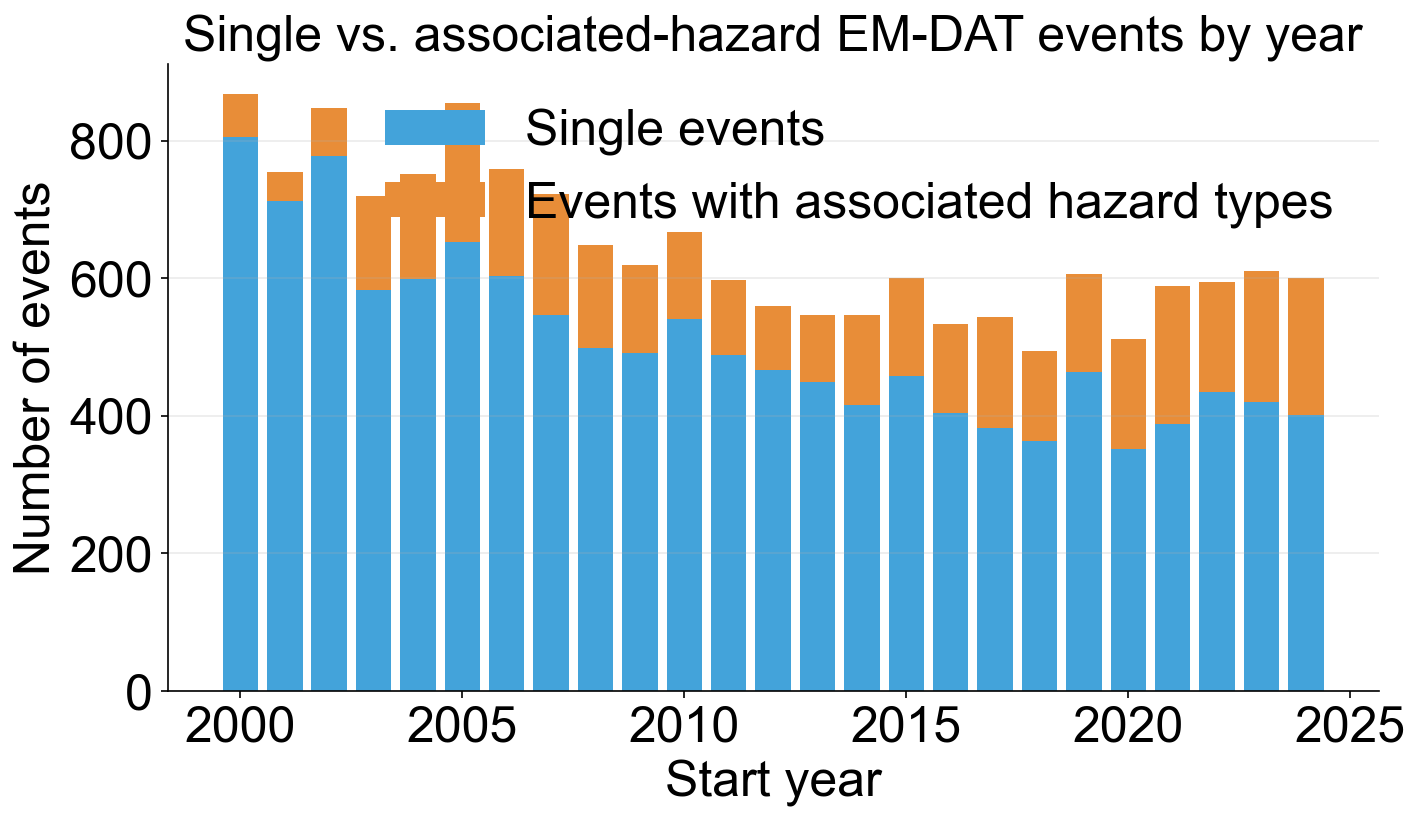

In [177]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

ax.bar(year_summary["Start Year"], year_summary["NonCompound_Count"], label="Single events", color="#43A3DA")
ax.bar(
    year_summary["Start Year"],
    year_summary["Compound_Count"],
    bottom=year_summary["NonCompound_Count"],
    label="Events with associated hazard types",
    color="#E88D38",
)

ax.set_title("Single vs. associated-hazard EM-DAT events by year")
ax.set_xlabel("Start year")
ax.set_ylabel("Number of events")
ax.legend(frameon=False)
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [178]:
region_summary = (
    emdat_df.groupby(["Region", "is_compound"])
    .size()
    .reset_index(name="Event_Count")
    .pivot_table(index="Region", columns="is_compound", values="Event_Count", fill_value=0)
    .rename(columns={False: "NonCompound_Count", True: "Compound_Count"})
    .reset_index()
)
region_summary["Total_Count"] = region_summary["NonCompound_Count"] + region_summary["Compound_Count"]
region_summary["Compound_pct"] = region_summary["Compound_Count"] / region_summary["Total_Count"]
region_summary.sort_values("Compound_Count", ascending=False)


is_compound,Region,NonCompound_Count,Compound_Count,Total_Count,Compound_pct
2,Asia,5103.0,1398.0,6501.0,0.215044
1,Americas,2173.0,1015.0,3188.0,0.318381
0,Africa,3666.0,489.0,4155.0,0.117690
3,Europe,1481.0,416.0,1897.0,0.219294
4,Oceania,277.0,129.0,406.0,0.317734


In [179]:
country_summary = (
    emdat_df.groupby(["Country", "is_compound"])
    .size()
    .reset_index(name="Event_Count")
    .pivot_table(index="Country", columns="is_compound", values="Event_Count", fill_value=0)
    .rename(columns={False: "NonCompound_Count", True: "Compound_Count"})
    .reset_index()
)
country_summary["Total_Count"] = country_summary["NonCompound_Count"] + country_summary["Compound_Count"]
country_summary["Compound_pct"] = country_summary["Compound_Count"] / country_summary["Total_Count"]

country_summary.sort_values("Compound_Count", ascending=False).head(20)


is_compound,Country,NonCompound_Count,Compound_Count,Total_Count,Compound_pct
212,United States of America,415.0,301.0,716.0,0.420391
39,China,1122.0,229.0,1351.0,0.169504
152,Philippines,302.0,171.0,473.0,0.361522
90,Indonesia,417.0,144.0,561.0,0.256684
89,India,686.0,129.0,815.0,0.158282
25,Brazil,175.0,89.0,264.0,0.337121
97,Japan,114.0,86.0,200.0,0.430000
217,Viet Nam,153.0,85.0,238.0,0.357143
124,Mexico,182.0,80.0,262.0,0.305344
42,Colombia,141.0,59.0,200.0,0.295000


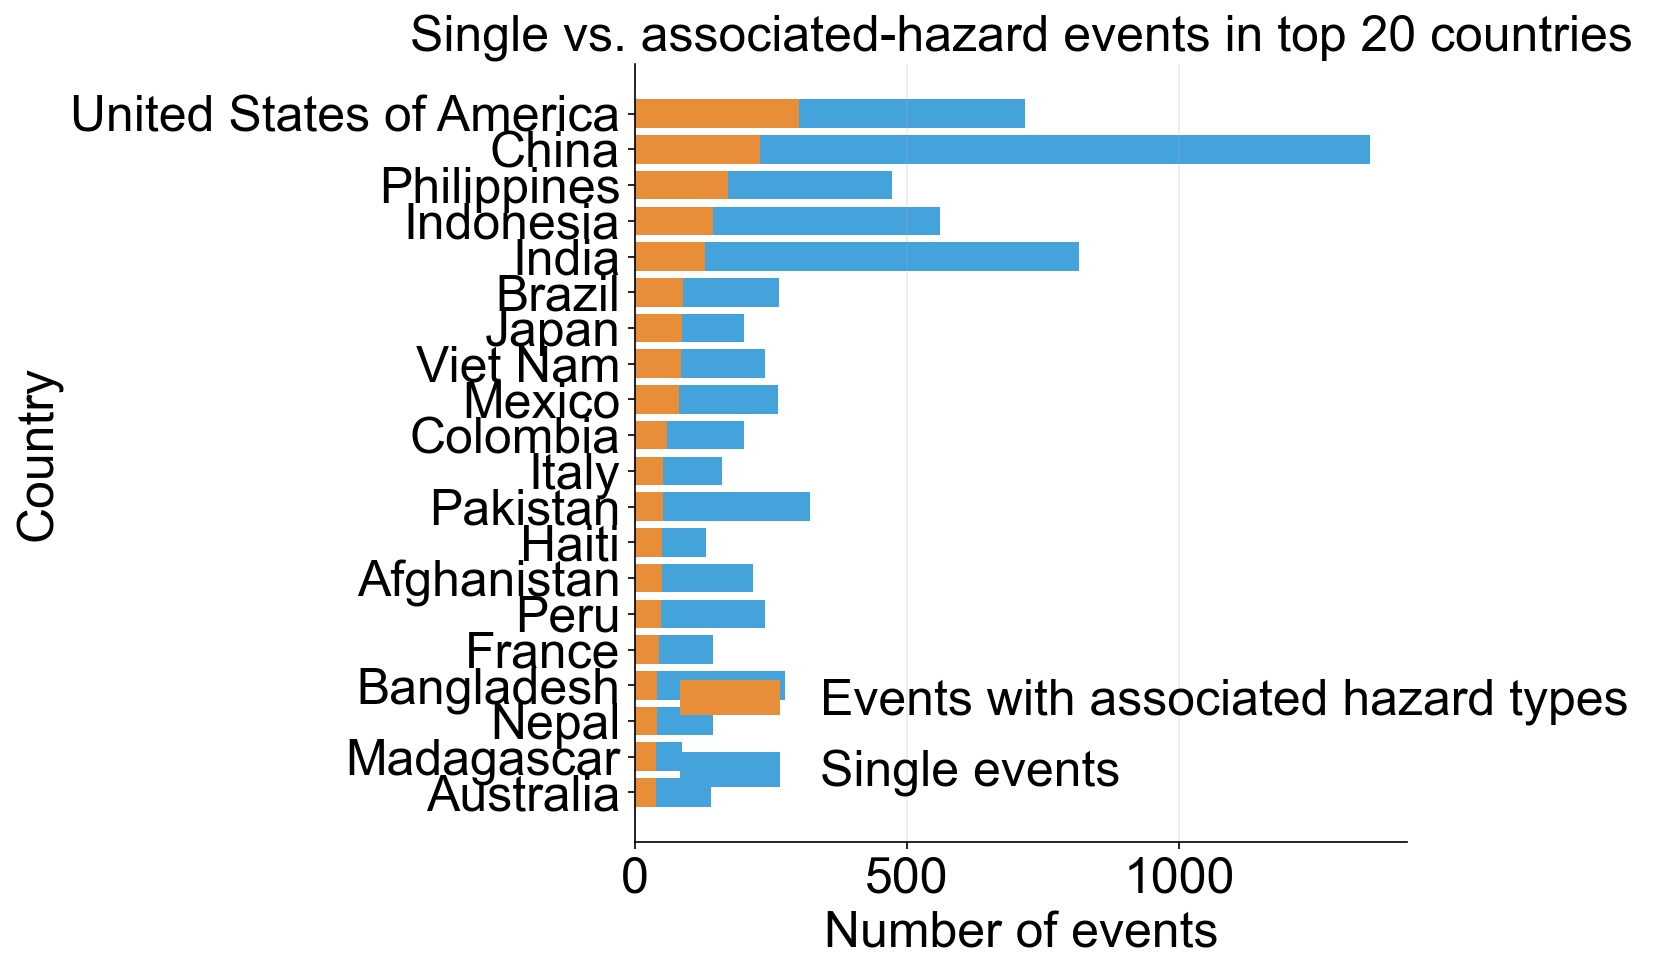

In [180]:
top20_country = country_summary.sort_values("Compound_Count", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7), dpi=150)
ax.barh(top20_country["Country"], top20_country["Compound_Count"], label="Events with associated hazard types", color="#E88D38")
ax.barh(top20_country["Country"], top20_country["NonCompound_Count"], left=top20_country["Compound_Count"], label="Single events", color="#43A3DA")

ax.set_xlabel("Number of events")
ax.set_ylabel("Country")
ax.set_title("Single vs. associated-hazard events in top 20 countries")
ax.invert_yaxis()
ax.legend(frameon=False)
ax.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


## 9. Compound Hazard Trend and Economic Loss

This section uses a precomputed workbook with `Count` and `Damage` sheets. It is optional because the workbook may be generated outside this notebook. If the file is unavailable, update `TREND_WORKBOOK` in the configuration cell or skip this section.


In [181]:
def load_trend_sheet(workbook: Path, sheet_name: str) -> pd.DataFrame:
    """Load a trend sheet and standardize fields used by the plotting functions."""
    df = pd.read_excel(require_file(workbook, "compound trend workbook"), sheet_name=sheet_name)
    df = df.copy()
    df["Single disasters"] = df["All recorded natural disasters"] - df["Natural disasters involving associated hazard types"]
    df["Start Year"] = df["Start Year"].astype(int)
    if df["Percentage (%)"].max() > 1.5:
        df["Percentage (%)"] = df["Percentage (%)"] / 100.0
    return df


trend_data_available = TREND_WORKBOOK.exists()

if trend_data_available:
    count_df = load_trend_sheet(TREND_WORKBOOK, "Count")
    damage_df = load_trend_sheet(TREND_WORKBOOK, "Damage")

    print(f"Count rows: {count_df.shape[0]:,}")
    print(f"Damage rows: {damage_df.shape[0]:,}")
    print(count_df.head())
else:
    print(f"Trend workbook not found, so trend/loss cells will be skipped: {TREND_WORKBOOK}")


Count rows: 25
Damage rows: 25
   Start Year  All recorded natural disasters  \
0        2000                             500   
1        2001                             430   
2        2002                             488   
3        2003                             386   
4        2004                             393   

   Natural disasters involving associated hazard types  Percentage (%)  \
0                                                 51          0.102000   
1                                                 29          0.067442   
2                                                 53          0.108607   
3                                                123          0.318653   
4                                                130          0.330789   

   Single disasters  
0               449  
1               401  
2               435  
3               263  
4               263  


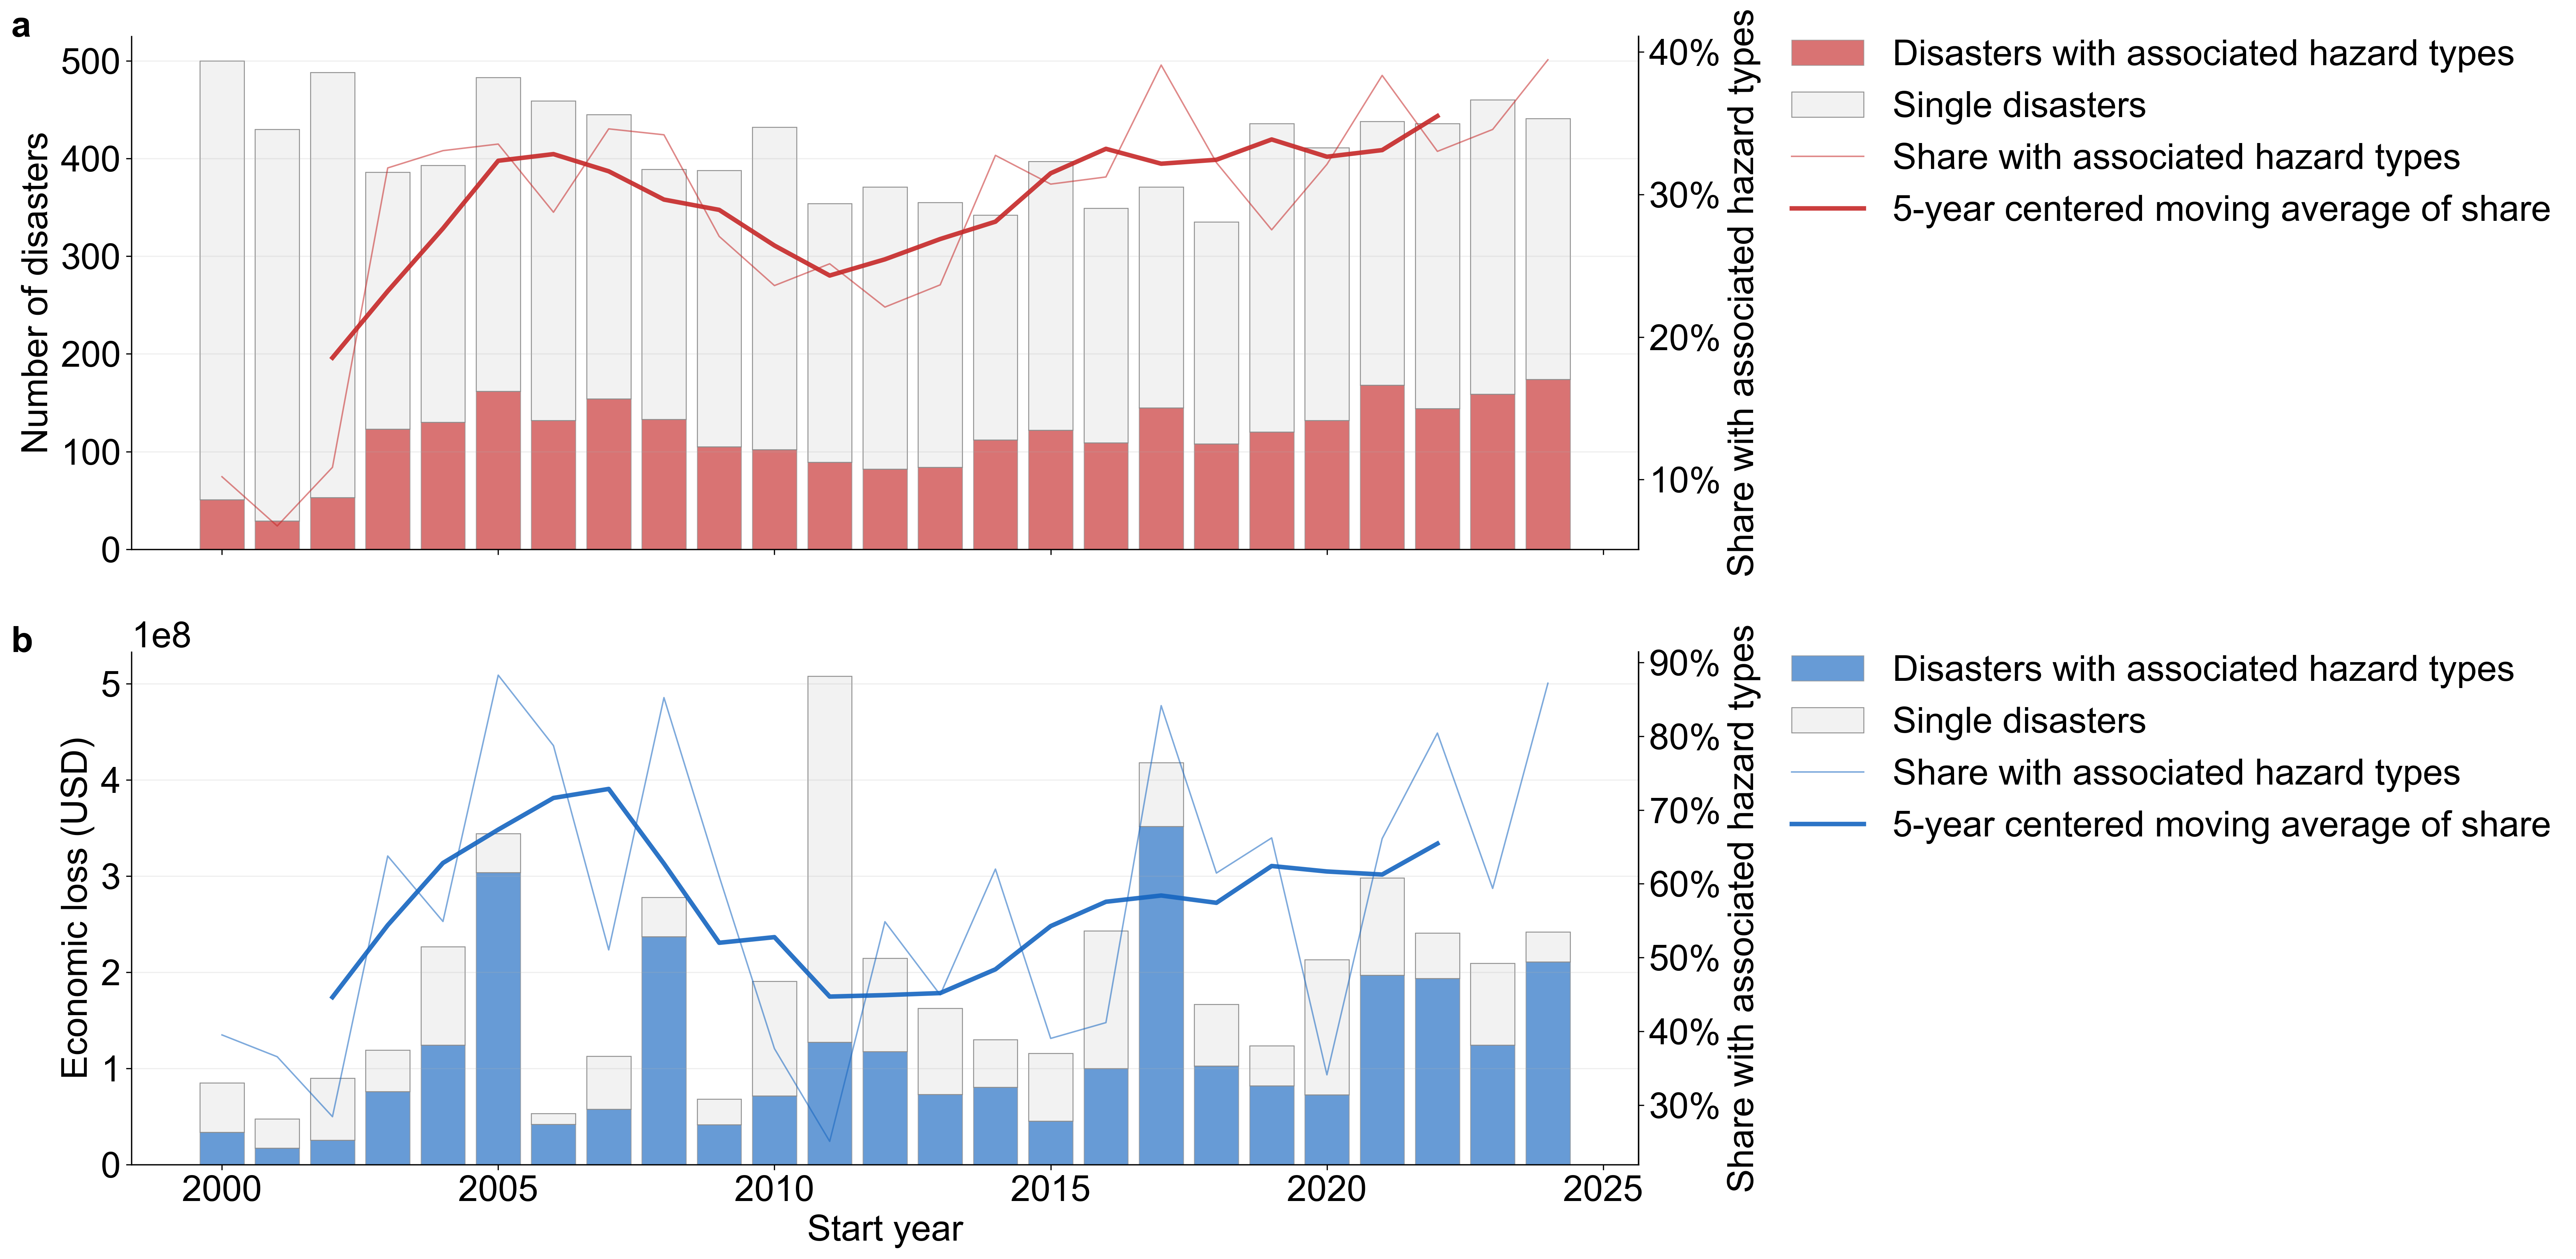

In [191]:
def plot_stacked_counts_with_share(
    ax: plt.Axes,
    df: pd.DataFrame,
    left_ylabel: str,
    compound_color: str,
    share_label: str
) -> None:
    """Plot stacked annual counts with a secondary-axis associated-hazard share."""
    df_s = df.sort_values("Start Year").copy()
    years = df_s["Start Year"].to_numpy()
    single = df_s["Single disasters"].to_numpy()
    compound = df_s["Natural disasters involving associated hazard types"].to_numpy()
    share = df_s["Percentage (%)"].to_numpy()

    ax.bar(
        years, compound,
        color=compound_color,
        alpha=0.65,
        edgecolor="0.55",
        linewidth=0.6,
        label="Disasters with associated hazard types"
    )

    ax.bar(
        years, single,
        bottom=compound,
        color="0.95",
        edgecolor="0.55",
        linewidth=0.6,
        label="Single disasters"
    )

    ax.set_ylabel(left_ylabel)
    ax.grid(True, axis="y", alpha=0.20)

    ax2 = ax.twinx()

    # Force secondary-axis spine to be visible
    ax2.spines["right"].set_visible(True)
    ax2.spines["right"].set_linewidth(1.0)
    ax2.spines["right"].set_color("black")
    ax2.tick_params(axis="y", which="both", right=True, labelright=True)

    ax2.plot(
        years, share,
        color=compound_color,
        alpha=0.55,
        linewidth=1.0,
        label=share_label
    )

    moving_average = (
        df_s["Percentage (%)"]
        .rolling(window=5, center=True, min_periods=5)
        .mean()
    )

    ax2.plot(
        years, moving_average,
        color=compound_color,
        linewidth=3,
        alpha=0.90,
        label="5-year centered moving average of share"
    )

    ax2.set_ylabel(share_label)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()

    ax2.legend(
        h1 + h2,
        l1 + l2,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.08, 0.81)
    )


if trend_data_available:

    plt.rcParams.update({
    "font.size": 24,
    "axes.titlesize": 24,
    "axes.labelsize": 24,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 24,
    })
    
    fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True, dpi=300)

    plot_stacked_counts_with_share(axes[0], count_df, "Number of disasters", "#C62828", "Share with associated hazard types")
    plot_stacked_counts_with_share(axes[1], damage_df, "Economic loss (USD)", "#1565C0", "Share with associated hazard types")

    for label, ax in zip(["a", "b"], axes):
        ax.text(-0.08, 1.05, label, transform=ax.transAxes, fontsize=24, fontweight="bold", va="top")

    axes[1].set_xlabel("Start year")
    fig.subplots_adjust(hspace=0.20, top=0.95, bottom=0.08)

    if EXPORT_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(OUTPUT_DIR / "Natural_assoc_trend.png", dpi=600, bbox_inches="tight", facecolor="white")

    plt.show()
else:
    print("Skipped trend/loss two-panel plot because the trend workbook is unavailable.")


In [142]:
try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except Exception as exc:
    HAS_STATSMODELS = False
    print(f"Statsmodels is unavailable, so statistical trend tests will be skipped: {exc}")


def trend_test(df: pd.DataFrame, label: str):
    """Run an OLS trend test with robust standard errors for associated-hazard share."""
    model_df = df.rename(columns={"Start Year": "year", "Percentage (%)": "share"}).copy()
    if model_df["share"].max() > 1.5:
        model_df["share"] = model_df["share"] / 100.0
    model_df["year_centered"] = model_df["year"] - model_df["year"].mean()

    x = sm.add_constant(model_df["year_centered"])
    y = model_df["share"]
    model = sm.OLS(y, x).fit(cov_type="HC3")

    print(f"\n===== Trend Test: {label} =====")
    print(model.summary())
    return model


if trend_data_available and HAS_STATSMODELS:
    model_events = trend_test(count_df, "Associated-Hazard Event Share")
    model_loss = trend_test(damage_df, "Associated-Hazard Economic Loss Share")
elif trend_data_available:
    print("Skipped statistical trend tests because statsmodels is unavailable.")
else:
    print("Skipped statistical trend tests because the trend workbook is unavailable.")



===== Trend Test: Associated-Hazard Event Share =====
                            OLS Regression Results                            
Dep. Variable:                  share   R-squared:                       0.384
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     8.955
Date:                Sat, 20 Jun 2026   Prob (F-statistic):            0.00650
Time:                        12:23:01   Log-Likelihood:                 32.315
No. Observations:                  25   AIC:                            -60.63
Df Residuals:                      23   BIC:                            -58.19
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

## 10. Optional Exports

Set `EXPORT_OUTPUTS = True` in the setup cell to write cleaned tables and figures to `OUTPUT_DIR`. Keeping exports opt-in makes the notebook safe to rerun during review.


In [190]:
if EXPORT_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    emdat_natural_assoc.to_csv(OUTPUT_DIR / "emdat_natural_associated_hazards.csv", index=False)
    frequent_subtype.to_csv(OUTPUT_DIR / "frequent_subtypes.csv", index=False)
    undirected_df.to_csv(OUTPUT_DIR / "hazard_cooccurrence_pairs.csv", index=False)
    robustness_summary.to_csv(OUTPUT_DIR / "community_robustness_summary.csv", index=False)
    robustness_assignments.to_csv(OUTPUT_DIR / "community_robustness_assignments.csv", index=False)
    year_summary.to_csv(OUTPUT_DIR / "compound_events_by_year.csv", index=False)
    region_summary.to_csv(OUTPUT_DIR / "compound_events_by_region.csv", index=False)
    country_summary.to_csv(OUTPUT_DIR / "compound_events_by_country.csv", index=False)
    print(f"Exported tables to {OUTPUT_DIR}")
else:
    print("Exports are disabled. Set EXPORT_OUTPUTS = True to write tables and figures.")


Exported tables to C:\Users\hai\OneDrive - Georgia Institute of Technology\06_Research_PRJ_2025_Review\code\compound-hazard-review\output\emdat
